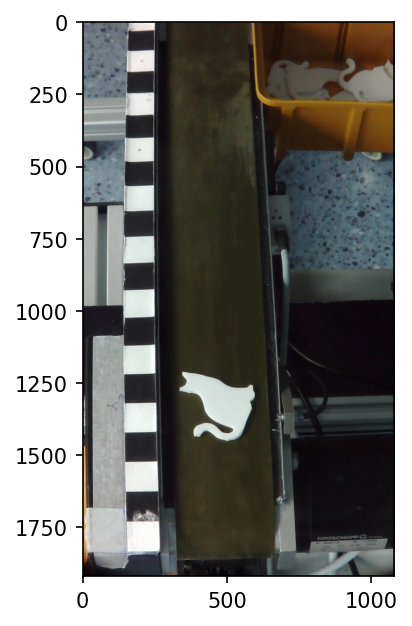

In [12]:
import cv2 as cv
from cv2 import aruco
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['figure.dpi'] = 150
plt.rcParams['savefig.dpi'] = 150

aruco_dict = aruco.getPredefinedDictionary(aruco.DICT_4X4_100)
parameters = aruco.DetectorParameters()
detector = aruco.ArucoDetector(aruco_dict, parameters)

img_aruco = cv.imread('aruco_pic/aruco_0.png')
img_obj = cv.imread('obj/cat/foto_10.png')

img_aruco_rotated = cv.rotate(img_aruco,2)
img_obj_rotated = cv.rotate(img_obj, 2)

SRC_COORDS = (np.array([[[ 0.,  0.],  [60., 0.],   [60., 60.],  [ 0.,60.], 
                                [ 0., 222.], [60., 222.], [60., 282.], [ 0., 282.]]], dtype= np.float32))

plt.imshow(img_obj_rotated)

In [13]:
corners, ids, rejected = detector.detectMarkers(img_aruco_rotated)
dstPoints = np.concatenate(corners, axis=1)
H, _ = cv.findHomography(srcPoints=SRC_COORDS, dstPoints=dstPoints, method=0)
H_inv = np.linalg.inv(H)
pts1 = np.float32([
    corners[1][0][0],  # oben-links
    corners[1][0][1],  # oben-rechts
    corners[0][0][3],  # unten-links
    corners[0][0][2],  # unten-rechts
])

pts1_reshaped = pts1.astype(np.float32).reshape(-1, 1, 2)

# Pixel in Bild zu welt
world_frame = cv.perspectiveTransform(pts1_reshaped, H_inv)

# versatz - mit X und Y Offsets
offset_raw = np.array([
    [-6, +6],  # mm - X offset -6, Y offset -6
    [+6, +6],  # mm - X offset +6, Y offset -6
    [-6, -6],  # mm - X offset -6, Y offset +6
    [+6, -6]   # mm - X offset +6, Y offset +6
], dtype=np.float32)

offset = offset_raw.reshape(-1, 1, 2)
pts1_2 = world_frame + offset

In [14]:
pts1_2_pixel = cv.perspectiveTransform(pts1_2, H)

In [15]:
min_x = np.min(pts1_2_pixel[:, 0, 0])
max_x = np.max(pts1_2_pixel[:, 0, 0])
min_y = np.min(pts1_2_pixel[:, 0, 1])
max_y = np.max(pts1_2_pixel[:, 0, 1])

width = int(max_x - min_x)
height = int(max_y - min_y)

pts2_proportional = np.float32([
    [0, 0],
    [width, 0],
    [0, height],
    [width, height]
])
M = cv.getPerspectiveTransform(pts1_2_pixel, pts2_proportional)

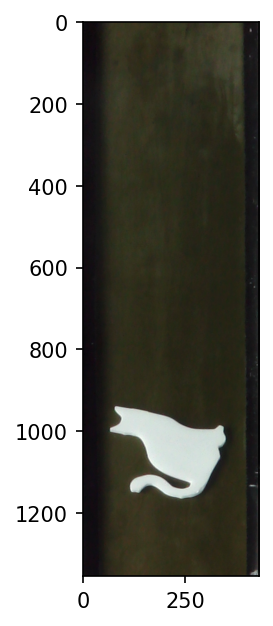

In [16]:
work_image = cv.warpPerspective(img_obj_rotated, M, (width, height))
plt.imshow(work_image)

/tmp/ipykernel_12882/560193099.py:1: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.10; the parameter will become keyword-only in 3.12.
  plt.hist(work_image.ravel(), 256, [0,256])


(array([0.0000e+00, 2.0000e+00, 1.0000e+00, 1.0000e+00, 2.0000e+00,
        1.5000e+01, 4.6000e+01, 1.6000e+02, 4.6400e+02, 1.2950e+03,
        2.6970e+03, 4.4730e+03, 7.6360e+03, 9.7980e+03, 1.2163e+04,
        1.4028e+04, 1.6229e+04, 2.1223e+04, 2.2361e+04, 2.6554e+04,
        3.4772e+04, 4.3104e+04, 5.0668e+04, 5.8992e+04, 5.1289e+04,
        5.0576e+04, 4.5532e+04, 4.6522e+04, 4.1717e+04, 3.4658e+04,
        3.3432e+04, 3.0041e+04, 2.7947e+04, 2.7412e+04, 2.7331e+04,
        3.6948e+04, 4.1657e+04, 4.6958e+04, 4.2960e+04, 4.6055e+04,
        4.1457e+04, 4.2252e+04, 4.1624e+04, 4.4005e+04, 4.6975e+04,
        4.7972e+04, 4.6653e+04, 3.9900e+04, 4.2822e+04, 3.5772e+04,
        3.3674e+04, 3.0387e+04, 2.8227e+04, 2.6079e+04, 2.1755e+04,
        1.7993e+04, 1.5942e+04, 1.2927e+04, 1.1136e+04, 8.8560e+03,
        7.3250e+03, 5.8740e+03, 5.2750e+03, 3.9020e+03, 3.4990e+03,
        3.0040e+03, 2.9660e+03, 2.9020e+03, 2.7550e+03, 2.6300e+03,
        2.4650e+03, 2.0950e+03, 1.7910e+03, 1.35

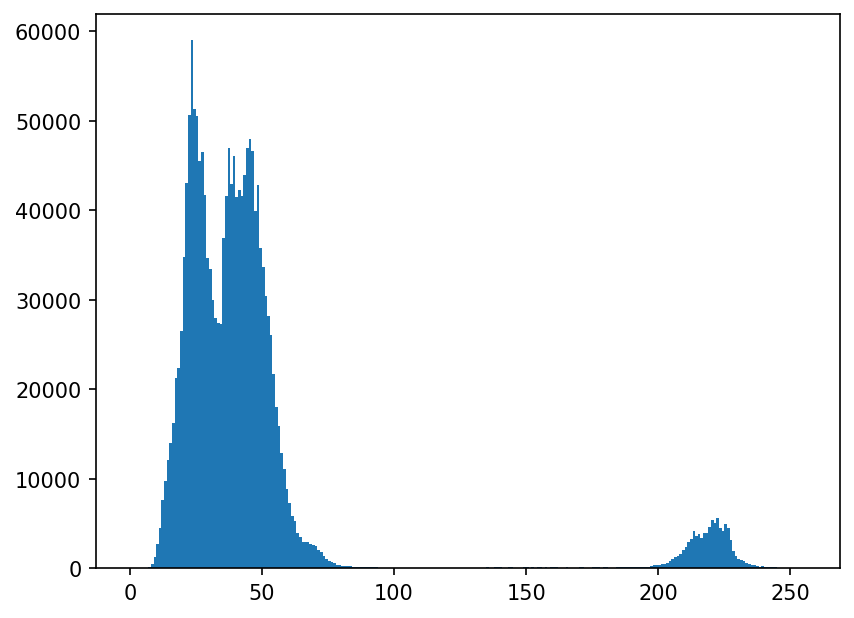

In [17]:
plt.hist(work_image.ravel(), 256, [0,256])

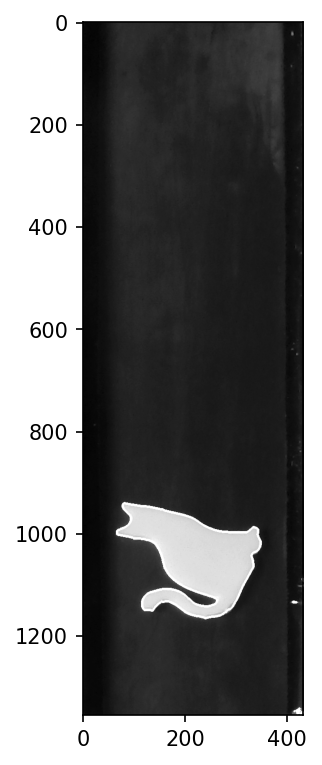

In [18]:
gray_image = cv.cvtColor(work_image, cv.COLOR_BGR2GRAY)

ret , img_thresh = cv.threshold(gray_image, 150, 255,cv.THRESH_BINARY)

uint8_img_thresh = img_thresh.astype(np.uint8)

contours , hierarchy = cv.findContours(uint8_img_thresh, cv.RETR_EXTERNAL, cv.CHAIN_APPROX_NONE)

img_with_contours = gray_image.copy()

cv.drawContours(img_with_contours, contours, contourIdx= -1 , color= (255, 255, 255),thickness=3)

plt.figure(figsize=(8, 6))
plt.imshow(img_with_contours, cmap='gray')

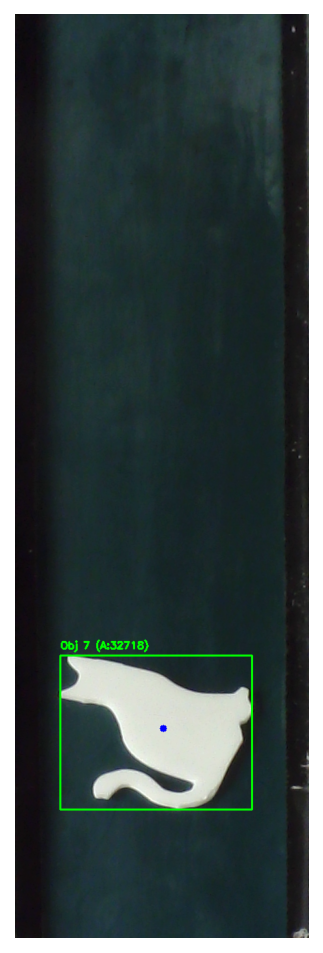

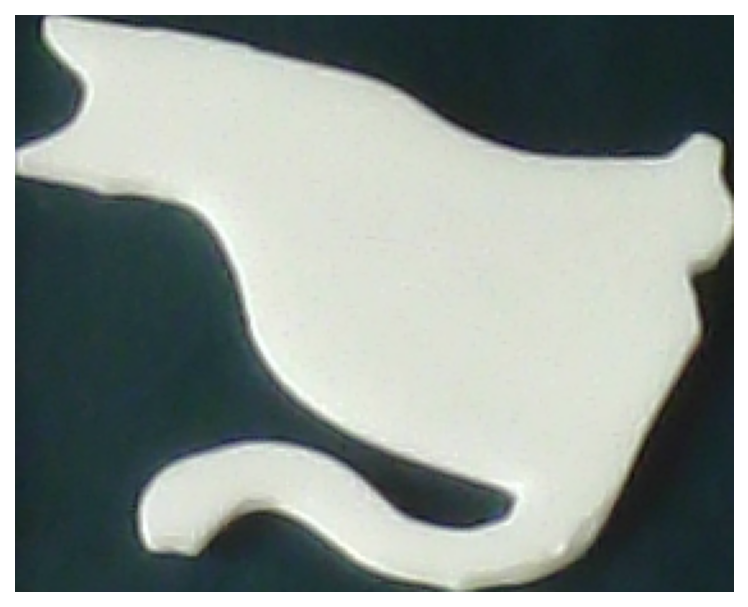

In [19]:
img_with_objects = work_image.copy()

objekte_roi = [] # Ausschnitt der relevanten RoIs

for i, cnt in enumerate(contours):
                                        # Filter für kleine Objekte
    area = cv.contourArea(cnt)
    if area < 50:                        # Schwellenwert
        continue
                                        # Bounding Box
    x, y, w, h = cv.boundingRect(cnt)
                                        # Objekt ausschneiden
    roi = work_image[y:y+h, x:x+w]
    objekte_roi.append(roi)
                                        # Schwerpunkt berechnen
    M = cv.moments(cnt)
    if M["m00"] != 0:
        cX = int(M["m10"] / M["m00"])
        cY = int(M["m01"] / M["m00"])
    else:
        cX, cY = 0, 0
        
    cv.rectangle(img_with_objects, (x, y), (x+w, y+h), (0, 255, 0), 2)
    cv.circle(img_with_objects, (cX, cY), 5, (255, 0, 0), -1)
    cv.putText(img_with_objects, f"Obj {i} (A:{int(area)})", (x, y - 10), 
               cv.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)

plt.figure(figsize=(10, 8))
plt.imshow(cv.cvtColor(img_with_objects, cv.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

# Wenn du die einzelnen Ausschnitte sehen willst:
if objekte_roi:
    fig, axes = plt.subplots(1, len(objekte_roi), figsize=(15, 5))
    if len(objekte_roi) == 1:
        axes = [axes]
    for ax, roi in zip(axes, objekte_roi):
        ax.imshow(cv.cvtColor(roi, cv.COLOR_BGR2RGB))
        ax.axis('off')
    plt.show()

In [20]:
def extract_features_from_contour(cnt):
    features = {}
    
    # 1. Basis-Werte
    features['area'] = cv.contourArea(cnt)
    features['perimeter'] = cv.arcLength(cnt, True)
    
    # Schutz vor Division durch Null bei Rauschen
    if features['area'] == 0 or features['perimeter'] == 0:
        return None 
        
    # 2. Polygon & Ecken
    epsilon = 0.04 * features['perimeter']
    approx = cv.approxPolyDP(cnt, epsilon, True)
    features['corners'] = len(approx)
    
    # 3. Bounding Box & Seitenverhältnis
    x, y, w, h = cv.boundingRect(cnt)
    features['aspect_ratio'] = float(w) / h
    
    # 4. Circularity
    features['circularity'] = (4 * np.pi * features['area']) / (features['perimeter'] ** 2)
    
    # 5. Hu-Momente (geben wir als flache Liste mit dazu)
    M = cv.moments(cnt)
    hu = cv.HuMoments(M).flatten()
    for i in range(7):
        features[f'hu_{i}'] = hu[i]
        
    return features



In [21]:
all_features = []
for cnt in contours:
    if cv.contourArea(cnt) > 500: # Rauschen filtern
        feat = extract_features_from_contour(cnt)
        if feat is not None:
            all_features.append(feat)#

all_features

[{'area': 32718.0,
  'perimeter': 1236.513842344284,
  'corners': 6,
  'aspect_ratio': 1.2433628318584071,
  'circularity': 0.26890485731230374,
  'hu_0': np.float64(0.22088423488468856),
  'hu_1': np.float64(0.0057857319073678646),
  'hu_2': np.float64(0.0029255528933008835),
  'hu_3': np.float64(0.00034355192129785684),
  'hu_4': np.float64(2.0036713532267685e-07),
  'hu_5': np.float64(2.463192975057262e-05),
  'hu_6': np.float64(2.8014359708095723e-07)}]